# ERA5 Data Download

<Axes: >

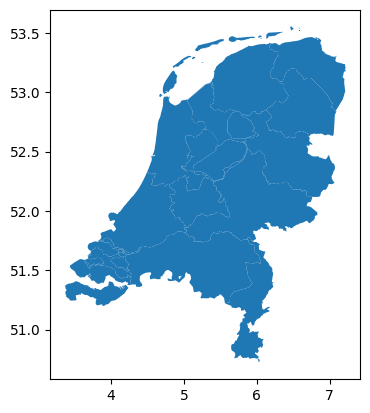

In [1]:
import atlite,pandas as pd,geopandas as gpd,matplotlib.pyplot as plt,pypsa
fn='gadm_410-levels-adm_1-nld.gpkg'
regions=gpd.read_file(fn)
regions.plot()

In [2]:
fn='era5-2013-nl.nc'
bounds=regions.total_bounds
cutout2=atlite.Cutout(path=fn,
                      module='era5',
                      time='2013',
                      x=slice(bounds[0],
                              bounds[2]),
                      y=slice(bounds[1],
                              bounds[3]))
cutout2

<Cutout "era5-2013-nl">
 x = 3.50 ⟷ 7.00, dx = 0.25
 y = 50.75 ⟷ 53.50, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5
 prepared_features = []

# Global Equal-Area, Distance CRS

<Axes: >

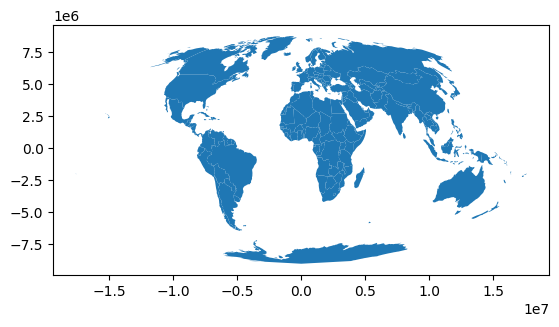

In [3]:
AREA_CRS='ESRI:54009'
DISTANCE_CRS='EPSG:4087'
world=gpd.read_file('ne_110m_admin_0_countries.zip')
world.to_crs(AREA_CRS).plot()

<Axes: >

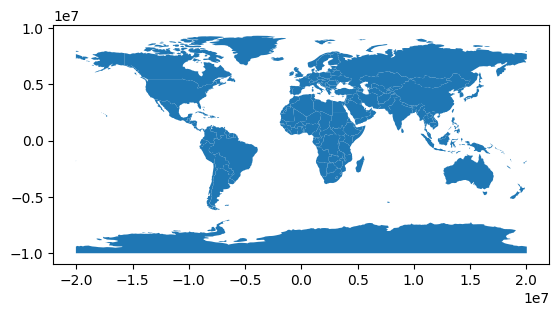

In [4]:
world.to_crs(DISTANCE_CRS).plot()

# Representative Points, Crow-Fly Distances

<Axes: >

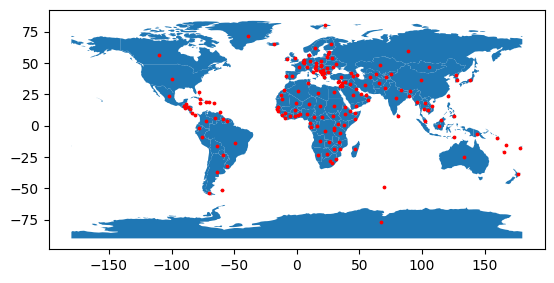

In [5]:
points=world.representative_point()
fig,ax=plt.subplots()
world.plot(ax=ax)
points.plot(ax=ax,
            color='red',
            markersize=3)

In [6]:
points=points.to_crs(4087)
points.index=world.ISO_A3
distances=pd.concat({k:points.distance(p) for k,p in points.items()},axis=1).div(1e3)
distances.loc['DEU','NLD']

np.float64(564.4945392494385)

# Gurobi Solver Setup

In [7]:
n=pypsa.examples.ac_dc_meshed()

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/v1.1.2/examples/networks/ac-dc-meshed/ac-dc-meshed.nc.
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
